# Risk-Based Auto-Deleveraging: Numerical Example

This notebook reproduces the numerical example from Section 4 of
*Risk-Based Auto-Deleveraging* (Campbell, Hey, Nutz, Moallemi, 2026).

We illustrate the optimal ADL allocation under a bivariate GBM price model
for BTC and ETH, and compare the full model against the one-factor
approximation of Section 3. The solver computes the population expectation
analytically (one-factor: closed form, GBM: Gauss-Hermite quadrature) and
solves the dual problem via gradient ascent with exact line search.

In [ ]:
import sys
sys.path.insert(0, '..')  

from adl import solve_adl,solve_adl_fast2, solve_water_filling
from adl import compute_leverage, compute_factor_leverage

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from matplotlib.lines import Line2D

## Market and Account Parameters

We fix the account state at the ADL time $\tau$ and consider $n=4$
cross-margin accounts, all short BTC but with differing ETH exposures.
Spot prices are calibrated to February 2026 levels. See Table 1 of the
paper for the full account state.

In [2]:
# =============================================================================
# Market parameters
# =============================================================================
np.random.seed(42)

p_tau = np.array([67000.0, 1900.0])
sigma_ann = np.array([0.6, 0.75])
Delta = 10 / 365
sigma = sigma_ann * np.sqrt(Delta)
rho = 0.85

# Covariance of price increments
Sigma_dp = np.outer(p_tau, p_tau) * np.array([
    [sigma[0]**2, rho*sigma[0]*sigma[1]],
    [rho*sigma[0]*sigma[1], sigma[1]**2]
])
eigvals, eigvecs = np.linalg.eigh(Sigma_dp)
lam1 = eigvals[-1]
u1 = eigvecs[:, -1]
if u1.sum() < 0: u1 = -u1
v = np.sqrt(lam1) * u1  # factor direction, eps ~ N(0,1)

# =============================================================================
# Account parameters (placeholder — adjust later)
# =============================================================================
# Positions: q[i] = [q_BTC, q_ETH], positive = short, negative = long
q = np.array([
    [8.0,   323.0],    # Account 1: short BTC, short ETH
    [10.0, -38.7],     # Account 2: short BTC, long ETH
    [8.0,   326.2],    # Account 3: short BTC, short ETH
    [7.0,  -190.0],    # Account 4: short BTC, long ETH
])

# Margins (in dollars)
m = np.array([137500.0, 85300.0, 75400.0, 43900.0])

# Entry prices (calibrated to match equity values from Table 1)
p_entry = np.array([
    [72000.0, 2100.0],   # Account 1
    [73544.0, 2100.0],   # Account 2
    [80000.0, 1904.0],   # Account 3
    [80143.0, 2000.0],   # Account 4
])

n, d = q.shape


## Solving the ADL Problem

For each value of $Q^{\mathrm{BTC}}$, we solve the expected-loss
minimization

$$\min_{x \in \mathcal{X}} \mathbb{E}[\mathcal{L}(x, p_T)]$$

under both the one-factor model and the full bivariate GBM, using
the dual gradient ascent solver. The dual variable $\lambda^*$ is
warm-started from the previous $Q$ value to speed up the sweep.

In [25]:
n_accounts = 4
Q_BTC_max = sum(q[i, 0] for i in range(n_accounts) if q[i, 0] > 0)
Q_BTC_values = np.arange(0.5, Q_BTC_max - 0.5, 0.1) #np.linspace(0.5, Q_BTC_max - 0.5, 20)
Q_ETH = 0.0

lam_prev = None
results_gbm = {'Q': [], 'obj':[],'ell': [], 'ell_v': []}

for Q_BTC in Q_BTC_values:
    print(Q_BTC)
    Q = np.array([Q_BTC, Q_ETH])
    result = solve_adl(Q, q, p_entry, p_tau, m,
                       mode='gbm',v = v, sigma=sigma_ann, Delta=Delta, rho=rho,
                                  lam_init=lam_prev)
    x, obj, lam_prev, success = result
    if success:
        results_gbm['Q'].append(Q_BTC)
        results_gbm['obj'].append(obj)
        results_gbm['ell'].append(compute_leverage(x, q, p_tau, p_entry, m))
        results_gbm['ell_v'].append(compute_factor_leverage(x, q, p_tau, p_entry, m,v))

for key in ['Q', 'obj', 'ell', 'ell_v']:
    results_gbm[key] = np.array(results_gbm[key])


0.5
0.6
0.7
0.7999999999999999
0.8999999999999999
0.9999999999999999
1.0999999999999999
1.1999999999999997
1.2999999999999998
1.4
1.4999999999999998
1.5999999999999996
1.6999999999999997
1.7999999999999998
1.8999999999999997
1.9999999999999996
2.0999999999999996
2.1999999999999997
2.3
2.3999999999999995
2.4999999999999996
2.5999999999999996
2.6999999999999993
2.7999999999999994
2.8999999999999995
2.9999999999999996
3.0999999999999996
3.1999999999999993
3.2999999999999994
3.3999999999999995
3.499999999999999
3.599999999999999
3.6999999999999993
3.7999999999999994
3.8999999999999995
3.999999999999999
4.1
4.199999999999999
4.299999999999999
4.3999999999999995
4.499999999999999
4.599999999999999
4.699999999999999
4.799999999999999
4.899999999999999
4.999999999999999
5.099999999999999
5.199999999999999
5.299999999999999
5.399999999999999
5.499999999999999
5.599999999999999
5.699999999999999
5.799999999999999
5.899999999999999
5.999999999999999
6.099999999999999
6.199999999999998
6.299999999

In [6]:
results_1f1d = {'Q': [], 'obj':[],'ell': [], 'ell_v': []}
Q_BTC_max = sum(q[i, 0] for i in range(n_accounts) if q[i, 0] > 0)
Q_BTC_values = np.linspace(0.5, Q_BTC_max - 0.5, 20)
lam_prev = None
for Q_BTC in Q_BTC_values:
    Q = np.array([Q_BTC, 0.0])
    result = solve_adl(Q, q, p_entry, p_tau, m,
                       mode='one_factor', v=v,
                       lam_init=lam_prev)
    x, obj, lam_prev, success = result
    if success:
        results_1f1d['Q'].append(Q_BTC)
        results_1f1d['obj'].append(obj)
        results_1f1d['ell'].append(compute_leverage(x, q, p_tau, p_entry, m))
        results_1f1d['ell_v'].append(compute_factor_leverage(x, q, p_tau, p_entry, m,v))

for key in ['Q', 'obj', 'ell', 'ell_v']:
    results_1f1d[key] = np.array(results_1f1d[key])

In [20]:
results_wf = {'Q': [], 'obj':[],'ell': [], 'ell_v': []}
Q_BTC_max = sum(q[i, 0] for i in range(n_accounts) if q[i, 0] > 0)
Q_BTC_values = np.linspace(0.5, Q_BTC_max - 0.5, 20)
lam_prev = None
for Q_BTC in Q_BTC_values:
    Q = np.array([Q_BTC, 0.0])
    result = solve_water_filling(Q, q, p_entry, p_tau, m, v, tol=1e-12, verbose=False)
    x_wf, ell_wf, eta_star, obj = result
    results_wf['Q'].append(Q_BTC)
    results_wf['obj'].append(obj)
    results_wf['ell'].append(compute_leverage(x_wf, q, p_tau, p_entry, m))
    results_wf['ell_v'].append(compute_factor_leverage(x_wf, q, p_tau, p_entry, m,v))

for key in ['Q', 'obj', 'ell', 'ell_v']:
    results_wf[key] = np.array(results_wf[key])

In [15]:
def plot_fig4(Qp,ell_rn,ellv_rn):
        n_accounts = ell_rn.shape[1]

        # account linestyles
        linestyles = ['solid', 'dashed', 'dotted', 'dashdot']

        # --- Figure: main = Factor Leverage ---
        fig, ax = plt.subplots(figsize=(6.4, 4))

        # Individual Factor Leverages
        for i in range(n_accounts):
            ax.plot(
                Qp,
                ellv_rn[:, i],
                color='black',
                linewidth=1.3,
                linestyle=linestyles[i % len(linestyles)]
            )

        # Axes formatting
        ax.set_xlabel(r'$Q_{\mathrm{BTC}}$')
        ax.set_ylabel(r'Factor Leverage')
        ax.set_xlim([Qp.min(), Qp.max()])
        ax.set_ylim([np.min(ellv_rn)*1.1, np.max(ellv_rn)*2.])

        plt.tight_layout()

        # --- Inset: Effective leverage ---
        axins = inset_axes(
            ax,
            width="42%",
            height="42%",
            loc="upper left",
            bbox_to_anchor=(0.60, 0.07, 0.9, 0.9),
            bbox_transform=ax.transAxes,
            borderpad=0
        )

        for i in range(n_accounts):
            axins.plot(
                Qp,
                ell_rn[:, i],
                color='black',
                linewidth=1.3,
                linestyle=linestyles[i % len(linestyles)]
            )

        axins.set_xlabel(r'$Q_{\mathrm{BTC}}$', fontsize=12)
        axins.set_ylabel(r'Gross Leverage', fontsize=12)
        axins.set_xlim([Qp.min(), Qp.max()])
        axins.tick_params(axis='both', labelsize=10)

        for spine in axins.spines.values():
            spine.set_linewidth(0.8)

        # --- Legend outside ---
        account_lines = [
            Line2D(
                [0], [0],
                color='black',
                lw=1.5,
                linestyle=linestyles[i % len(linestyles)],
                label=fr'Account {i+1}'
                # optional math version:
                # label=fr'$\ell_{{{i+1}}}(x_{{{i+1}}})$'
            )
            for i in range(n_accounts)
        ]

        ax.legend(
            handles=account_lines,
            loc='center left',
            bbox_to_anchor=(1.02, 0.5),
            frameon=True
        )

        plt.subplots_adjust(right=0.80)
        plt.tight_layout()


def plot_fig4_panel(Qp, ell_rn, ellv_rn, ax, title=None):

    Qp = np.asarray(Qp, float)
    ell_rn = np.asarray(ell_rn, float)
    ellv_rn = np.asarray(ellv_rn, float)

    n_accounts = ell_rn.shape[1]

    colors = ['black'] * n_accounts
    linestyles = ['solid', 'dashed', 'dotted', 'dashdot']


    for i in range(n_accounts):
        ax.plot(
            Qp,
            ellv_rn[:, i],
            color=colors[i],
            linewidth=1.0,
            linestyle=linestyles[i % len(linestyles)]
        )

    ax.set_xlabel(r'$Q_{\mathrm{BTC}}$')
    ax.set_ylabel(r'Factor Leverage')
    ax.set_xlim([Qp.min(), Qp.max()])
    ax.set_ylim([np.min(ellv_rn) * 1.1, np.max(ellv_rn) * 2.2])

    if title is not None:
        ax.set_title(title)

    axins = inset_axes(
        ax,
        width="42%",
        height="42%",
        loc="upper left",
        bbox_to_anchor=(0.60, 0.06, 0.9, 0.9),
        bbox_transform=ax.transAxes,
        borderpad=0
    )

    for i in range(n_accounts):
        axins.plot(
            Qp,
            ell_rn[:, i],
            color=colors[i],
            linewidth=1.0,
            linestyle=linestyles[i % len(linestyles)]
        )

    axins.set_xlabel(r'$Q_{\mathrm{BTC}}$')
    axins.set_ylabel(r'Gross Leverage')
    axins.set_xlim([Qp.min(), Qp.max()])
    axins.tick_params(axis='both')

    for spine in axins.spines.values():
        spine.set_linewidth(0.8)

    return n_accounts


def plot_fig4_side_by_side(results_left, results_right):

    fig, axes = plt.subplots(
    1, 2,
    figsize=(12.8, 4),
    sharey=True
    )

    n_accounts_left = plot_fig4_panel(
        np.asarray(results_left["Q"], float),
        np.asarray(results_left["ell"], float),
        np.asarray(results_left["ell_v"], float),
        ax=axes[0]
    )

    n_accounts_right = plot_fig4_panel(
        np.asarray(results_right["Q"], float),
        np.asarray(results_right["ell"], float),
        np.asarray(results_right["ell_v"], float),
        ax=axes[1]
    )

    # remove right y-axis labels/ticks
    axes[1].set_ylabel("")
    axes[1].tick_params(labelleft=False)

    n_accounts = min(n_accounts_left, n_accounts_right)


    linestyles = ['solid', 'dashed', 'dotted', 'dashdot']
    legend_handles = [
        Line2D([0], [0], color='black', lw=1.8,
                linestyle=linestyles[i % len(linestyles)],
                label=fr'Account {i+1}')
        for i in range(n_accounts)
    ]

    fig.legend(
        handles=legend_handles,
        loc='center left',
        bbox_to_anchor=(0.88, 0.5),
        frameon=True
    )

    plt.subplots_adjust(right=0.88, wspace=0.05)

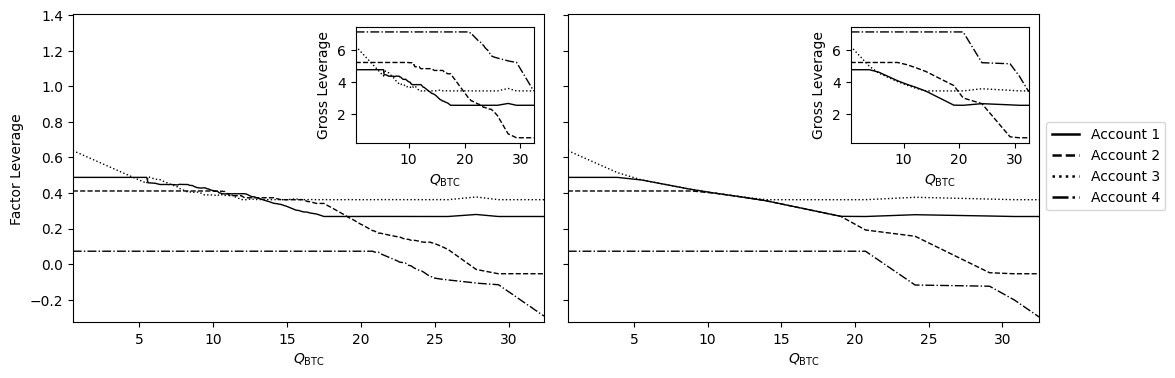

In [26]:
plot_fig4_side_by_side(
    results_left=results_gbm,
    results_right=results_1f1d
)

/var/folders/sc/k1sgxfg51tj3wf81kxl1tqyc0000gn/T/ipykernel_85517/207660057.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


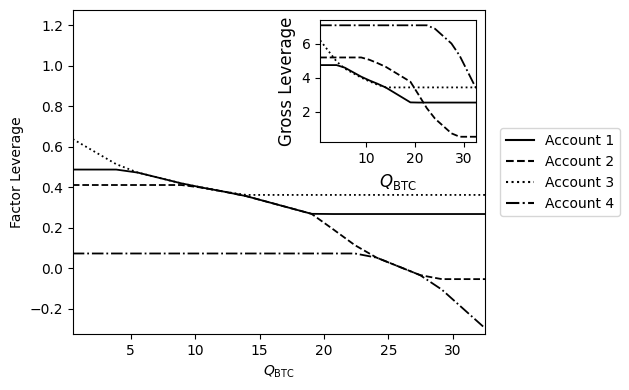

In [22]:
plot_fig4(np.asarray(results_wf["Q"], float),np.asarray(results_wf["ell"], float) ,
np.asarray(results_wf["ell_v"], float) )

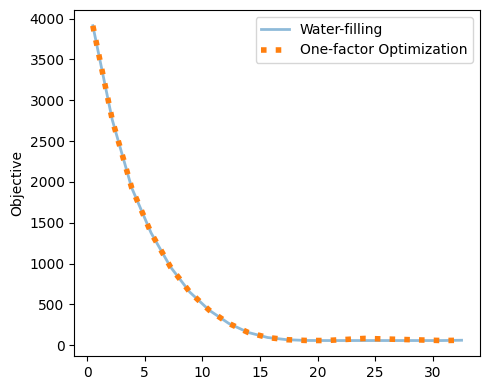

In [24]:
fig, ax = plt.subplots(figsize=(5, 4))
plt.plot(np.asarray(results_wf["Q"], float), np.asarray(results_wf["obj"], float), linewidth = 2, alpha = 0.5, label = 'Water-filling')
plt.plot(np.asarray(results_1f1d["Q"], float), np.asarray(results_1f1d["obj"], float),linestyle = 'dotted', linewidth = 4,
label = 'One-factor Optimization')
plt.ylabel('Objective')
plt.legend()
plt.tight_layout()

## Results: Factor Leverage After ADL

The plot shows post-ADL factor leverage $\ell_i^{(v)}$ for each account
as a function of $Q^{\mathrm{BTC}}$. Under the one-factor model, the
water-filling structure of Theorem 5 predicts that interior accounts
equalize their factor leverage at the water level $\eta^*$. The GBM
results confirm that the one-factor approximation is accurate for this
calibration.